# for each feature $j$, we look through hyperparams to find $l$ the smallest minimal loss.  We report both best param, optimized param, as well as the loss history for that $l$

In [8]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the base directory and expand the '~' to the home directory
base_dir = os.path.expanduser('~/project/53_hattie_marginal_estimation_results')

# Get all hyperparameter files
hyperparam_files = sorted(glob.glob(os.path.join(base_dir, 'hyperparameters_*.csv')))

# Extract all unique feature indices across all directories
all_feature_indices = set()
for hyperparam_file in hyperparam_files:
    # Extract 'l' from the filename
    l = os.path.splitext(os.path.basename(hyperparam_file))[0].split('_')[-1]
    l = int(l)

    # Directory containing loss histories
    loss_history_dir = os.path.join(base_dir, str(l))
    loss_files = glob.glob(os.path.join(loss_history_dir, 'loss_histories_dataset_0_feature_*.csv'))
    feature_indices = [
        int(os.path.splitext(os.path.basename(f))[0].split('_')[-1])
        for f in loss_files
    ]
    all_feature_indices.update(feature_indices)

# Dictionary to store the best results for each feature
best_results = {}

# Process each feature index
for j in sorted(all_feature_indices):
    best_result_for_j = None

    # Scan through all choices of `l`
    for hyperparam_file in hyperparam_files:
        # Extract 'l' from the filename
        l = os.path.splitext(os.path.basename(hyperparam_file))[0].split('_')[-1]
        l = int(l)

        # Directory containing data for this value of l
        data_dir = os.path.join(base_dir, str(l))

        # Paths to the necessary files for feature j
        loss_history_path = os.path.join(data_dir, f'loss_histories_dataset_0_feature_{j}.csv')
        best_params_path = os.path.join(data_dir, f'best_parameters_dataset_0_feature_{j}.csv')
        optimized_params_path = os.path.join(data_dir, f'optimized_parameters_dataset_0_feature_{j}.csv')

        # Check if all necessary files exist
        if all(os.path.exists(path) for path in [loss_history_path, best_params_path, optimized_params_path]):
            # Read the loss history for feature j
            loss_history_df = pd.read_csv(loss_history_path)
            loss_values = loss_history_df['loss'].values  # Assuming 'loss' is a column name

            # Find the smallest minimal loss for this `l`
            min_loss = np.min(loss_values)

            # Read the best and optimized parameters
            best_params_df = pd.read_csv(best_params_path)
            best_params = best_params_df.to_dict(orient='records')[0]  # Extract the row as a dictionary
            
            optimized_params_df = pd.read_csv(optimized_params_path)
            optimized_params = optimized_params_df.to_dict(orient='records')[0]  # Extract the row as a dictionary

            # Check if this result is the best so far for feature `j`
            if best_result_for_j is None or min_loss < best_result_for_j['min_loss']:
                best_result_for_j = {
                    'l': l,
                    'feature_index': j,
                    'min_loss': min_loss,
                    'best_params': best_params,
                    'optimized_params': optimized_params,
                    'loss_history': loss_values.tolist()
                }

    # Store the best result for this feature
    if best_result_for_j:
        best_results[j] = best_result_for_j

# Convert the results into a DataFrame
results_df = pd.DataFrame.from_dict(best_results, orient='index')
results_df

,l,feature_index,min_loss,best_params,optimized_params,loss_history
0,2,0,2594.292148,"{'alpha': 0.0869968561314576, 'nu': 1.05967051...","{'alpha': 0.0826428742993967, 'nu': 1.07906426...","[2594.6446025569376, 2594.510234704464, 2594.4..."
1,2,1,3003.131222,"{'alpha': 0.0284185574209425, 'nu': 1.23042350...","{'alpha': 0.0265407741013115, 'nu': 1.23172353...","[3305.1776419865128, 3300.01256478513, 3295.67..."
2,1,2,2713.930379,"{'alpha': 0.0219746498799788, 'nu': 1.58168810...","{'alpha': 0.0192836969106025, 'nu': 1.58425645...","[3108.253269212099, 3103.440393667338, 3096.73..."
3,2,3,2789.802488,"{'alpha': 0.0756848129366347, 'nu': 1.13474474...","{'alpha': 0.0725152133447193, 'nu': 1.14780940...","[2884.442595588432, 2864.1650959443214, 2850.3..."
4,3,4,3278.861936,"{'alpha': 0.1085714409509151, 'nu': 2.82949937...","{'alpha': 0.1090139822329975, 'nu': 2.84585207...","[3677.749266936878, 3677.00287655232, 3674.666..."
5,0,5,3202.501248,"{'alpha': 0.0666866089408232, 'nu': 1.67806720...","{'alpha': 0.0645121019972292, 'nu': 1.71322774...","[3292.7826892921366, 3293.8695009775797, 3294...."
6,0,6,3574.641569,"{'alpha': 0.0708434685139331, 'nu': 1.69586543...","{'alpha': 0.0699100491751199, 'nu': 1.71619933...","[3780.6481401103256, 3775.485000178756, 3766.9..."
7,6,7,3435.914674,"{'alpha': 0.1161314395423852, 'nu': 2.83866321...","{'alpha': 0.1162784408721433, 'nu': 2.85082748...","[4097.20213478167, 4073.891133819469, 4028.851..."
8,2,8,3612.991996,"{'alpha': 0.0719816743597522, 'nu': 1.27891432...","{'alpha': 0.0706848327693179, 'nu': 1.28375739...","[3781.9902531578864, 3783.3628994494575, 3783...."
9,1,9,3937.801698,"{'alpha': 0.0634051538819481, 'nu': 1.51006294...","{'alpha': 0.062720473325421, 'nu': 1.516432180...","[4181.535833424081, 4169.172268671307, 4159.94..."


In [9]:
# Save the results to a CSV file
results_output_path = os.path.join(base_dir, 'best_results_per_feature.csv')
results_df.to_csv(results_output_path, index=False)

print(f"Results saved to {results_output_path}")

Results saved to /gpfs/radev/home/zc362/project/53_hattie_marginal_estimation_results/best_results_per_feature.csv


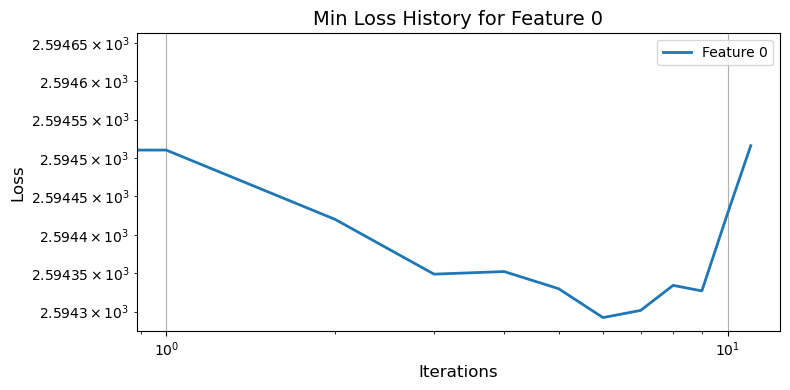

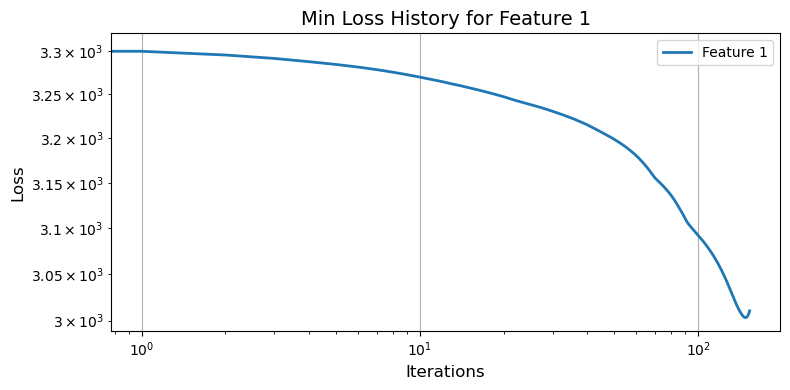

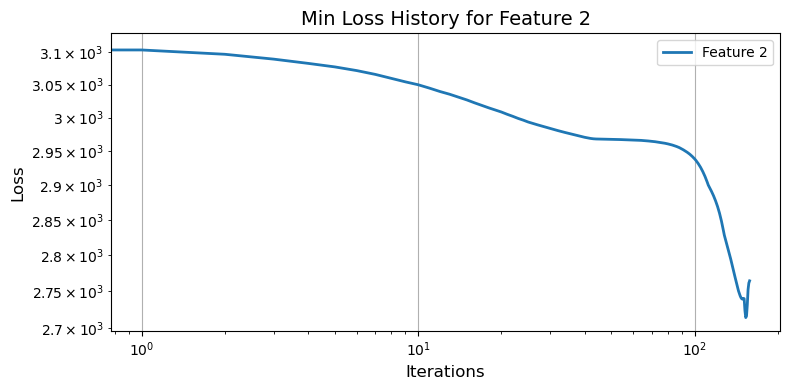

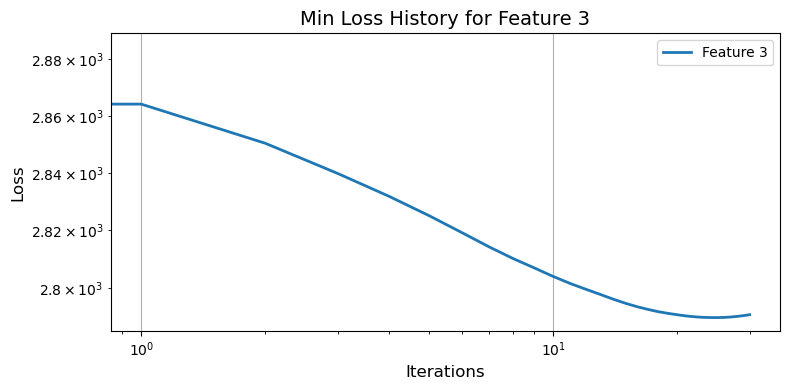

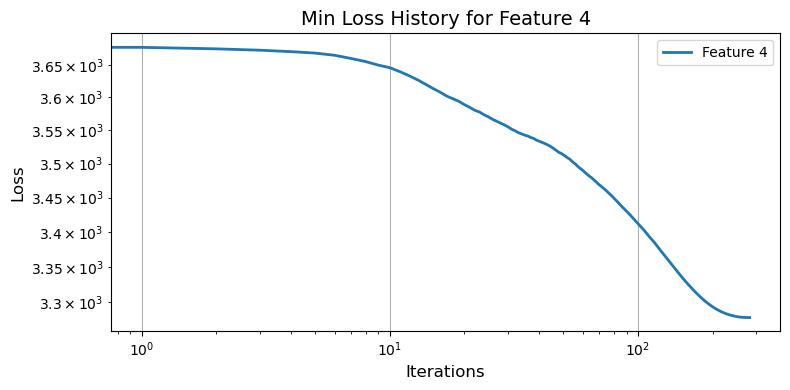

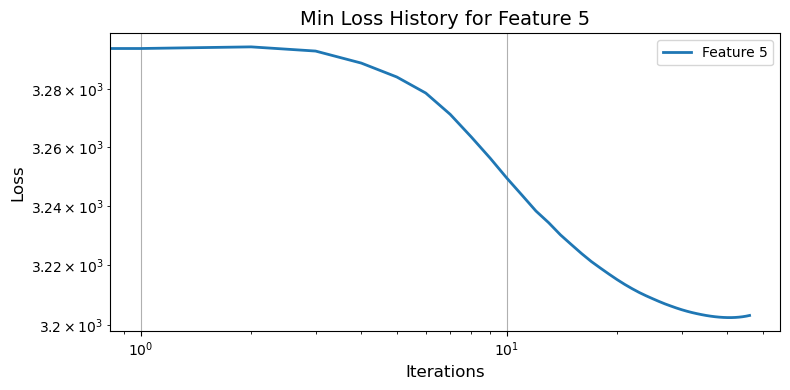

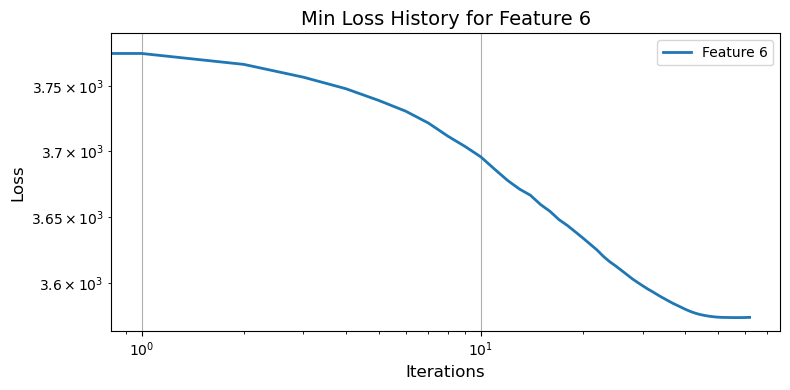

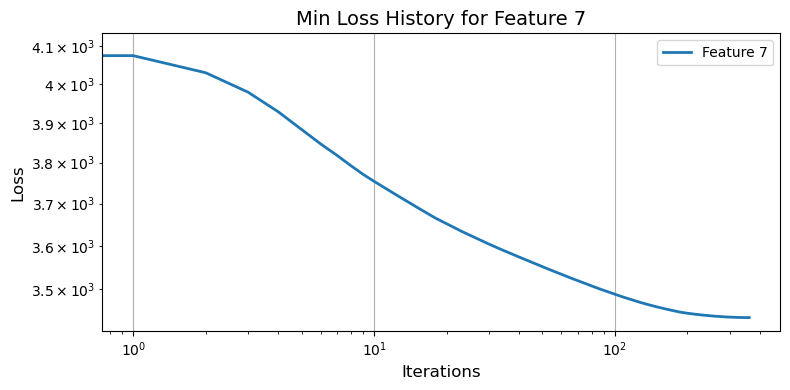

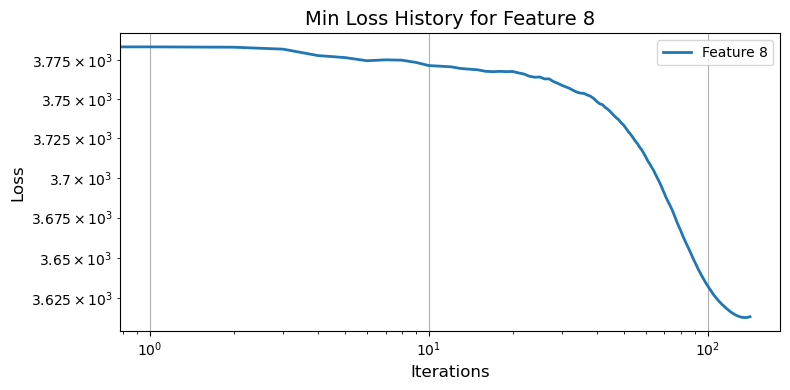

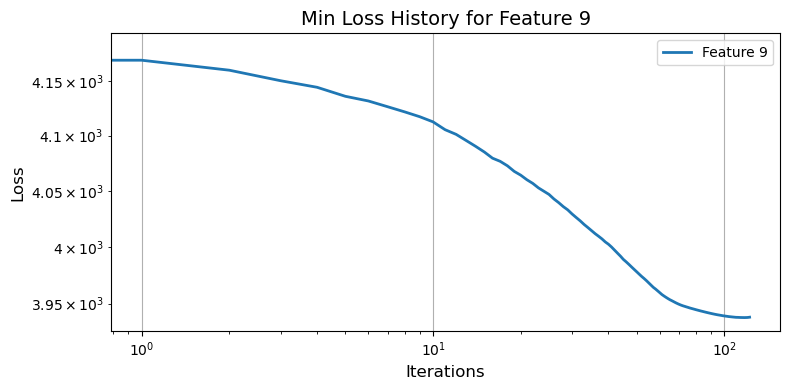

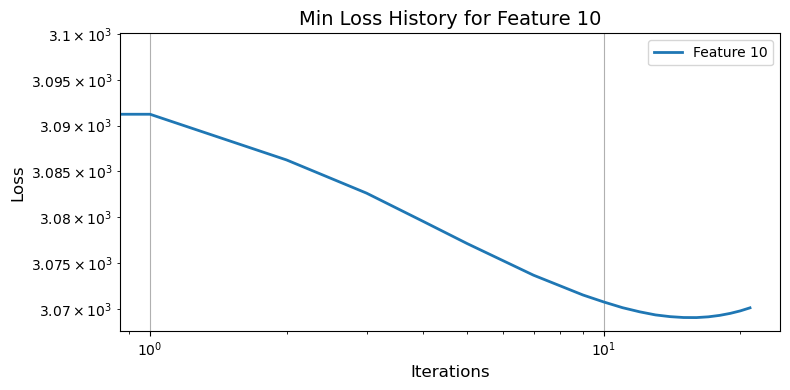

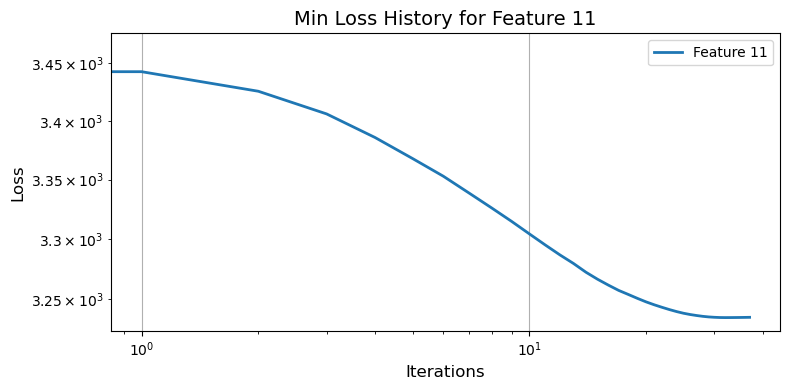

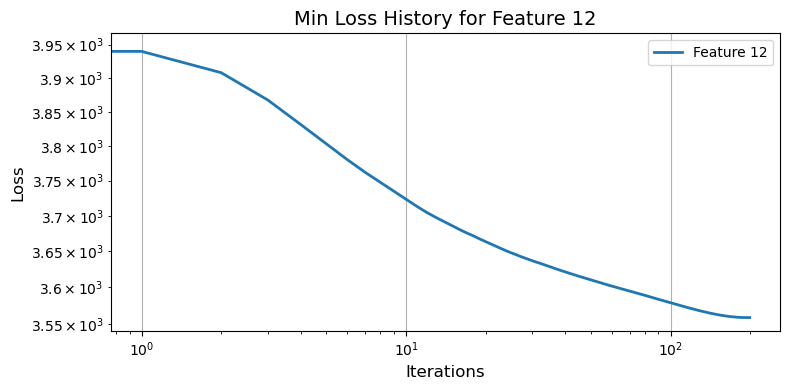

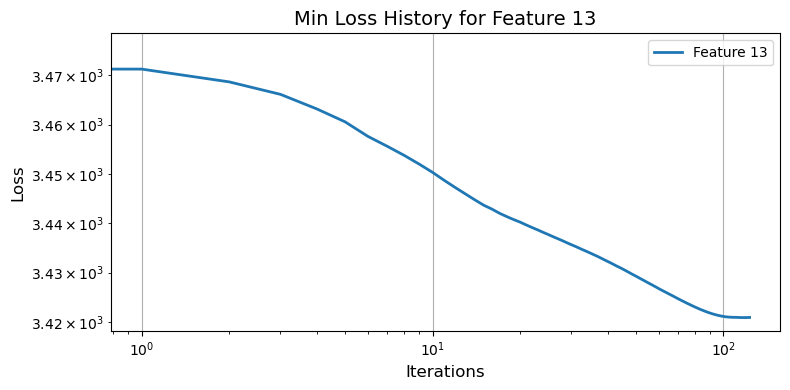

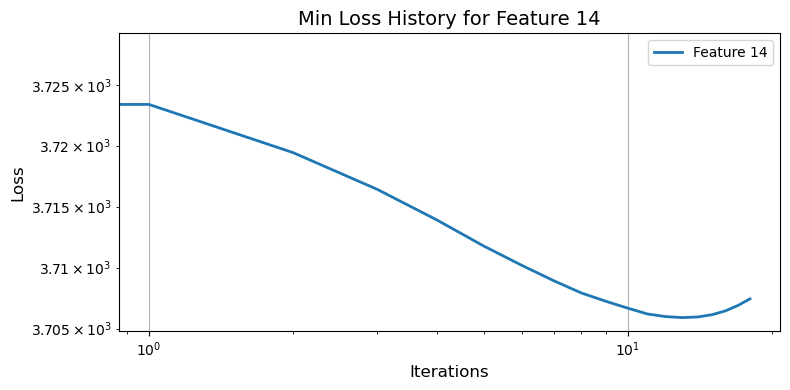

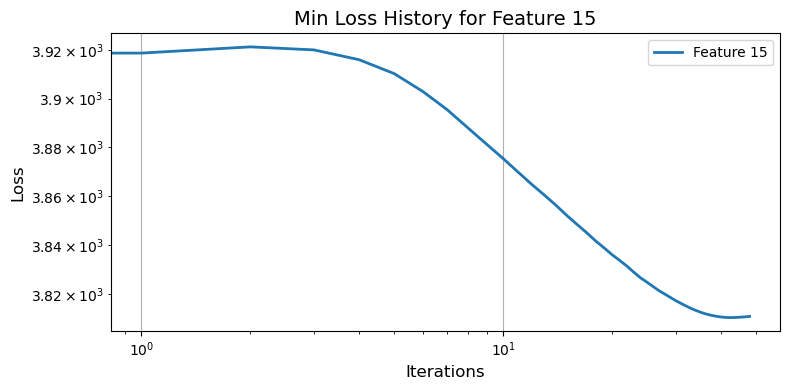

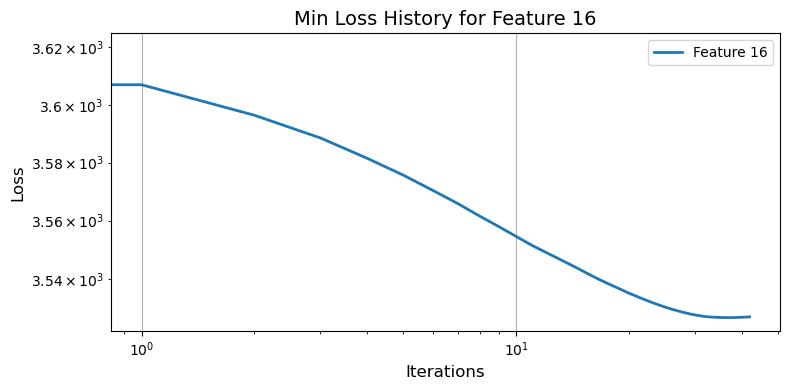

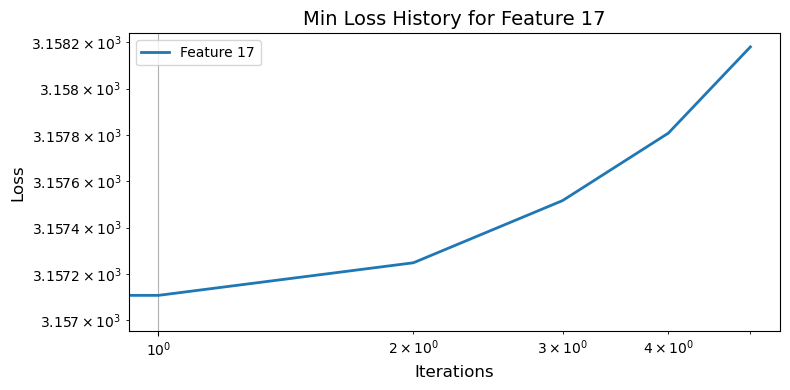

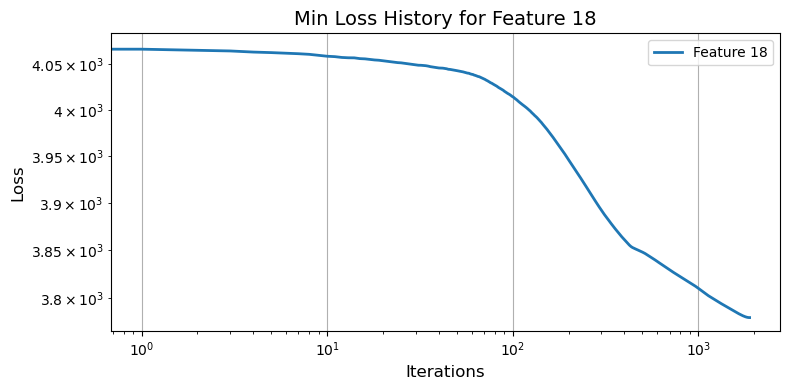

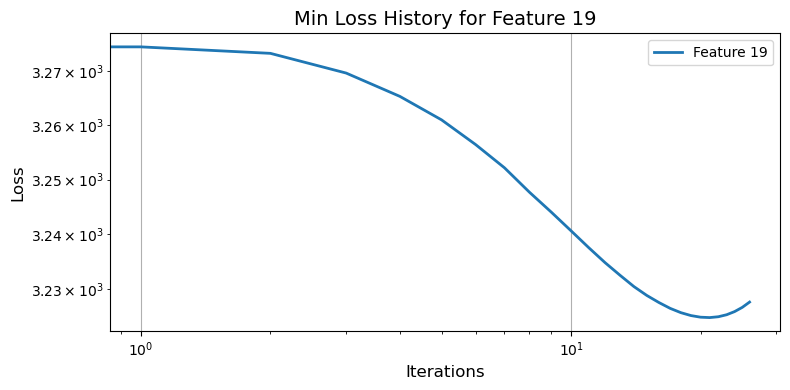

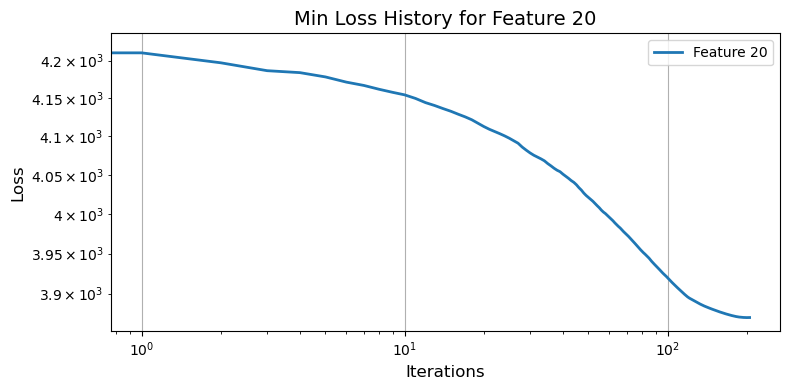

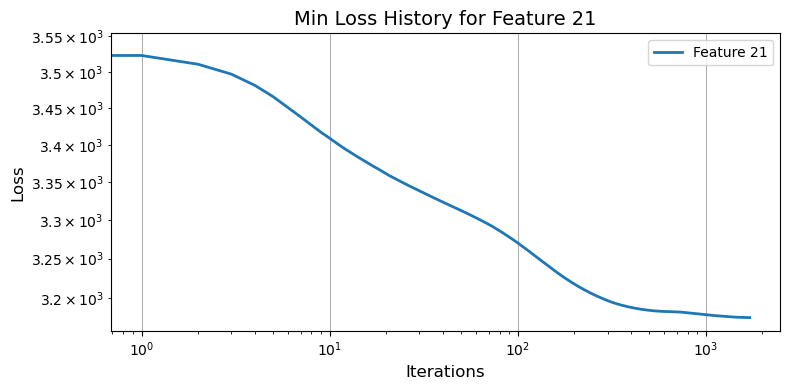

In [12]:
import matplotlib.pyplot as plt

# Plot each loss history from the DataFrame
for feature_index, loss_history in enumerate(results_df["loss_history"]):
    plt.figure(figsize=(8, 4))  # Create a new figure for each feature
    plt.plot(loss_history, label=f'Feature {feature_index}', linewidth=2)
    plt.title(f'Min Loss History for Feature {feature_index}', fontsize=14)
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
